Plan of the project:

- prepare the data - load xlsx file ✅
- get data properties using BioPython / pubchem ✅
- get embeddings for sequences ✅
- use simple models to classify the data (e.g., logistic regression, SVM) ✅
- classify the data using LSTM for each sequence of each category ✅
- compare the results of simple models and LSTM ✅

# Data loading and preparation


In [1]:
# preparing the unnecessarily complicated excel file

import pandas as pd
from pandas import DataFrame as PandasDataFrame
from typing import Callable, Dict, Tuple


DfsByTopLevelType = Dict[str, PandasDataFrame]
DfsByTopAndMidLevelType = Dict[Tuple[str, str], PandasDataFrame]


def convert_df_drop_names_rows_and_create_label_column(
    df: PandasDataFrame,
) -> PandasDataFrame:
    df = df[~df.apply(lambda row: row.str.contains(r">").any(), axis=1)]
    df = df.melt(
        value_vars=["Positive samples", "Negative samples"],
        var_name="label",
        value_name="sequence",
    )
    df = df.dropna(subset=["sequence"])
    df["label"] = df["label"].map({"Positive samples": 1, "Negative samples": 0})
    return df


def divide_df_to_multiindex_levels(
    df: PandasDataFrame,
) -> Tuple[DfsByTopLevelType, DfsByTopAndMidLevelType]:
    dfs_by_top_level: DfsByTopLevelType = {}
    for level0_key in df.columns.get_level_values(0).unique():
        dfs_by_top_level[level0_key] = df[level0_key]

    dfs_by_top_and_mid_level: DfsByTopAndMidLevelType = {}
    for level0_key, sub_df in dfs_by_top_level.items():
        for level1_key in sub_df.columns.get_level_values(0).unique():
            dfs_by_top_and_mid_level[(level0_key, level1_key)] = sub_df[level1_key]

    return dfs_by_top_level, dfs_by_top_and_mid_level


def iterate_over_dfs_by_top_and_mid_level_and_apply_function(
    dfs_by_top_and_mid_level: DfsByTopAndMidLevelType,
    function_to_apply: Callable[[PandasDataFrame], PandasDataFrame],
) -> DfsByTopAndMidLevelType:
    result_dfs: DfsByTopAndMidLevelType = {}
    for (top_level, mid_level), df in dfs_by_top_and_mid_level.items():
        result_dfs[(top_level, mid_level)] = function_to_apply(df)
    return result_dfs

In [2]:
# preparing the df
df = pd.read_excel("icarps.xlsx", header=[0, 1, 2], skiprows=2)
df = df.dropna(how="all", axis=0)  # dropping empty rows

df = df.drop(
    columns=[("Training samples", "Proline(P)", "Negative samples.1")]
)  # drop empty column

dfs_by_top_level, dfs_by_top_and_mid_level = divide_df_to_multiindex_levels(df)

dfs_by_top_and_mid_level = iterate_over_dfs_by_top_and_mid_level_and_apply_function(
    dfs_by_top_and_mid_level, convert_df_drop_names_rows_and_create_label_column
)  # all dfs in an object

In [3]:
# example of how to access the data: df options
subsets_names_terain_test = set([key[0] for key in dfs_by_top_and_mid_level.keys()])
subsets_names_protein = set([key[1] for key in dfs_by_top_and_mid_level.keys()])

print(f"Subsets names (train test): {subsets_names_terain_test}")
print(f"Subsets names (proteins): {subsets_names_protein}")

Subsets names (train test): {'Testing samples', 'Training samples'}
Subsets names (proteins): {'Threonine(T)', 'Proline(P)', 'Arginine(R)', 'Lysine(K)'}


### Enriching data with feature vectors derived from amino acid physicochemical properties

This step transforms each amino acid sequence into a numerical matrix, where each amino acid is represented by a vector of selected physicochemical properties. These properties are averaged and summed across the sequence to provide meaningful aggregate features.


Extract propreties from sequence


In [ ]:
# extract protein properties from sequence
from Bio.SeqUtils.ProtParam import ProteinAnalysis


# extract features
def compute_protein_properties(seq: str):
    seq = seq.replace("X", "")  # X - unidentifed amino acid, ommition
    s = ProteinAnalysis(seq)
    ss_fraction = s.secondary_structure_fraction()
    return pd.Series(
        {
            "molecular_weight": s.molecular_weight(),
            "isoelectric_point": s.isoelectric_point(),
            "instability_index": s.instability_index(), #protein stabiliti in solution
            "gravy": s.gravy(), #mean hydropathy index
            "aromaticity": s.aromaticity(),
            "helix_fraction": ss_fraction[0],
            "turn_fraction": ss_fraction[1],
            "sheet_fraction": ss_fraction[2],
        }
    )


# add to df
def enrich_df_with_sequence_protein_analysis(df: PandasDataFrame) -> PandasDataFrame:
    protein_properties = df["sequence"].apply(compute_protein_properties)

    df = pd.concat([df, protein_properties], axis=1)

    return df

In [5]:
# process data frames to add generated columns with sequence properties
dfs_by_top_and_mid_level_props = (
    iterate_over_dfs_by_top_and_mid_level_and_apply_function(
        dfs_by_top_and_mid_level, enrich_df_with_sequence_protein_analysis
    )
)

dfs_by_top_and_mid_level_props_no_x = (
    iterate_over_dfs_by_top_and_mid_level_and_apply_function(
        dfs_by_top_and_mid_level_props, lambda df: df[~df["sequence"].str.contains("X")]
    )
)

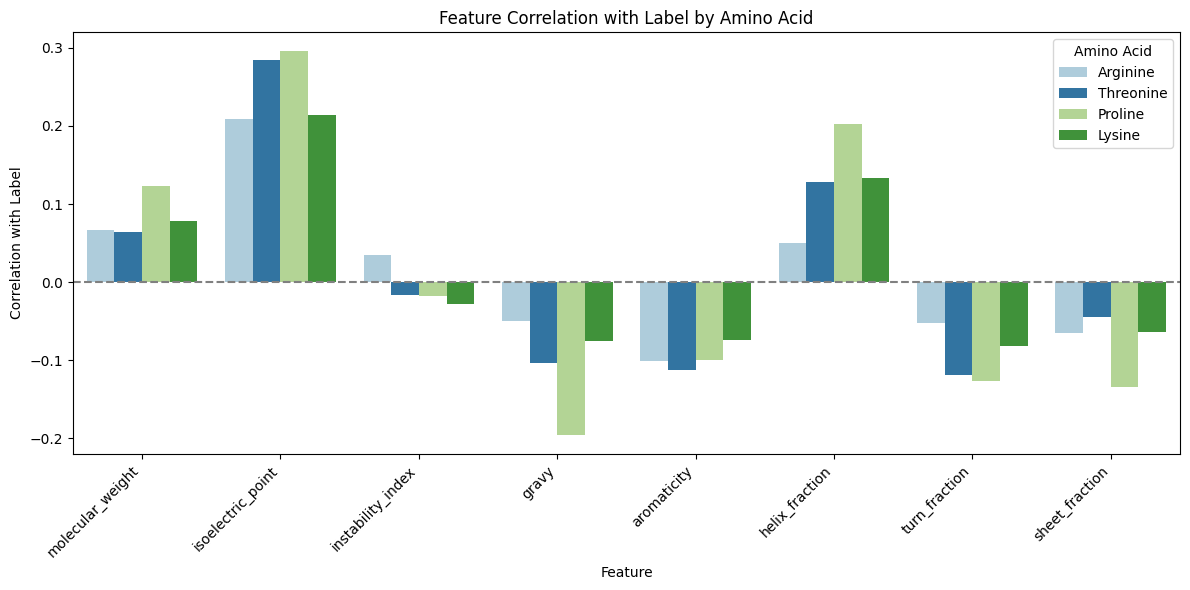

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

amino_acids = {
    "Arginine": dfs_by_top_and_mid_level_props["Training samples", "Arginine(R)"],
    "Threonine": dfs_by_top_and_mid_level_props["Training samples", "Threonine(T)"],
    "Proline": dfs_by_top_and_mid_level_props["Training samples", "Proline(P)"],
    "Lysine": dfs_by_top_and_mid_level_props["Training samples", "Lysine(K)"],
}

correlation_data = []

for name, df in amino_acids.items():
    df_clean = df.drop(columns=["sequence"])
    corr_series = df_clean.corr()["label"].drop("label")

    for feature, corr_value in corr_series.items():
        correlation_data.append(
            {"AminoAcid": name, "Feature": feature, "CorrelationWithLabel": corr_value}
        )

corr_df = pd.DataFrame(correlation_data)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=corr_df,
    x="Feature",
    y="CorrelationWithLabel",
    hue="AminoAcid",
    palette="Paired",
)
plt.title("Feature Correlation with Label by Amino Acid")
plt.ylabel("Correlation with Label")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, color="gray", linestyle="--")
plt.legend(title="Amino Acid")
plt.tight_layout()

plt.savefig("feature_label_correlation.png", dpi=300)
plt.show()

In [11]:
def count_sequences_containing_x(
    dfs_by_top_and_mid_level: DfsByTopAndMidLevelType,
) -> int:
    total_x_count = 0
    for (_, _), df in dfs_by_top_and_mid_level.items():
        seq_col = df["sequence"]
        for seq in seq_col:
            if seq.count("X") > 0:
                total_x_count += 1
    return total_x_count

total_xs = count_sequences_containing_x(dfs_by_top_and_mid_level_props)
print(f"Sequences that contain 1 or more X: {total_xs}")

print("Example sequences with X in Lysine(K):")
dfs_by_top_and_mid_level_props["Training samples", "Lysine(K)"][
    dfs_by_top_and_mid_level_props["Training samples", "Lysine(K)"][
        "sequence"
    ].str.contains("X")
].head(10)

Sequences that contain 1 or more X: 105
Example sequences with X in Lysine(K):


,label,sequence,molecular_weight,isoelectric_point,instability_index,gravy,aromaticity,helix_fraction,turn_fraction,sheet_fraction
230,1,XMGLVSSKKPDKEKPIKEKDKGQWSPL,2954.4432,9.602840,12.161538,-1.365385,0.038462,0.461538,0.384615,0.192308
1885,0,GILHAMDGFVDQKKKLXXXXXXXXXXX,1800.1296,8.505072,1.406250,-0.212500,0.062500,0.437500,0.250000,0.312500
1974,0,XXXXXXXXXMAKRKEENFSSPKNAKRP,2118.4197,10.446409,108.094444,-1.950000,0.055556,0.500000,0.333333,0.055556
1982,0,KAEGIIYTTQSTIKPXXXXXXXXXXXX,1649.8825,8.497594,11.593333,-0.380000,0.066667,0.266667,0.200000,0.466667
1996,0,STSLLVHPVSGVRKEQGGGCHSDTXXX,2451.6710,6.660473,42.037500,-0.433333,0.000000,0.166667,0.416667,0.291667
2090,0,REKDRLLAMAVIRKKHGMXXXXXXXXX,2152.6329,11.000257,6.350000,-0.672222,0.000000,0.555556,0.111111,0.222222
2192,0,GYRLQGPYMVKMLKXXXXXXXXXXXXX,1684.0772,9.997128,60.978571,-0.371429,0.142857,0.428571,0.214286,0.357143
2213,0,XXXXXXXXXMDDDKPFQPKNISKMAEL,2107.4068,4.682590,71.316667,-1.111111,0.055556,0.444444,0.388889,0.166667
2241,0,XXXMVEDELALFDKSINEFWNKFKSTD,2907.2091,4.425507,27.958333,-0.604167,0.166667,0.416667,0.291667,0.375000
2254,0,EEVKEFVKSMKEPKTEAXXXXXXXXXX,2009.2806,5.066935,47.858824,-1.252941,0.058824,0.647059,0.117647,0.235294


In [ ]:
# check that the sequences do not have X
dfs_by_top_and_mid_level_props_no_x[("Training samples", "Lysine(K)")].head(7)

dfs_by_top_and_mid_level_props_no_x["Training samples", "Lysine(K)"][
    dfs_by_top_and_mid_level_props_no_x["Training samples", "Lysine(K)"][
        "sequence"
    ].str.contains("X")
] # there are no sequences containig X

,label,sequence,molecular_weight,isoelectric_point,instability_index,gravy,aromaticity,helix_fraction,turn_fraction,sheet_fraction


Extract properties from amino acids


In [19]:
# download data index
import requests

url = "https://www.genome.jp/ftp/db/community/aaindex/aaindex1"
response = requests.get(url)

with open("aaindex1", "wb") as f:
    f.write(response.content)


# parse_aaindex1_modified was copied from chatGPT; its possible to use biopython-1.78 to unpack the data but it's painful
def parse_aaindex1_modified(path):
    aaindex = {}
    aa_order = []  # final order of single-letter amino acids
    current_entry = {}
    current_key = None
    reading_values = False
    value_lines = []

    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("H "):
                current_key = line[2:].strip()
                current_entry = {"description": "", "values": {}}
            elif line.startswith("D "):
                current_entry["description"] = line[2:].strip()
            elif line.startswith("I "):
                # Extract amino acid pairs and flatten them into a list of letters
                aa_pairs = line[1:].strip().split()
                aa_order = []
                for pair in aa_pairs:
                    aa_order.extend(pair.split("/"))
            elif line == "//":
                if current_key and value_lines:
                    # Flatten the value lines
                    values = []
                    for vl in value_lines:
                        try:
                            values += [float(x) for x in vl.strip().split()]
                        except ValueError:
                            continue
                    if len(values) == 20:
                        current_entry["values"] = dict(zip(aa_order, values))
                        aaindex[current_key] = current_entry
                # Reset state for next entry
                current_entry = {}
                value_lines = []
                aa_order = []
                reading_values = False
                current_key = None
            elif line and (line[0].isdigit() or line[0] == "-" or line[0] == " "):
                value_lines.append(line)

    return aaindex


aaindex = parse_aaindex1_modified("aaindex1")
# check if the aaindex is loaded correctly
print(f"Records found: {len(aaindex)}\n")

for key, record in aaindex.items():
    if "Hydrophobicity" in record["description"]:
        print("ID:", key)
        print("Desctiption:", record["description"])
        print("Hydrophobicity Ala:", record["values"].get("A"))
        break


Records found: 552

ID: ARGP820101
Desctiption: Hydrophobicity index (Argos et al., 1982)
Hydrophobicity Ala: 0.61


In [ ]:
# add features from aaindex1 to dataframe
import numpy as np
import pandas as pd
import json

selected_features = {
    "ARGP820101": "hydrophobicity",
    "CHAM820101": "side chain volume",
    "FAUJ880111": "molecular weight",
    "JANJ780101": "isoelectric point",
    "KYTJ820101": "helical propensity",
    "ROSM880102": "solvent accessible surface area",
    "ZIMJ680104": "molecular volume",
    "GRAR740102": "electric charge",
    "BHAR880101": "polarity",
    "OOBM770101": "side chain mobility",
    "TANS770106": "side chain spatial volume",
}


def sequence_to_feature_matrix(sequence):
    aaindex = parse_aaindex1_modified("aaindex1")
    feature_matrix = []
    for aa in sequence.upper():
        features = []
        for idx in selected_features:
            value = aaindex.get(idx, {}).get("values", {}).get(aa, np.nan)
            features.append(value)
        feature_matrix.append(features)
    return np.array(feature_matrix, dtype=np.float64)


def enrich_df_with_aaindex_features(df: pd.DataFrame) -> pd.DataFrame:

    def compute_features(seq):
        matrix = sequence_to_feature_matrix(seq)
        mean_per_feature = np.nanmean(matrix, axis=0)

        mean_per_feature_json = json.dumps(mean_per_feature.tolist())

        sum_per_feature = np.nansum(matrix, axis=0)
        sum_per_feature_json = json.dumps(sum_per_feature.tolist())

        return pd.Series(
            {
                "aaindex_mean_vector": mean_per_feature_json,
                "aaindex_sum_vector": sum_per_feature_json,
            }
        )

    features_df = df["sequence"].apply(compute_features)

    df = pd.concat(
        [
            df.drop(
                columns=["aaindex_mean_vector", "aaindex_sum_vector"], errors="ignore"
            ),
            features_df,
        ],
        axis=1,
    )
    return df

In [21]:
# add to df
dfs_by_top_and_mid_level_means = (
    iterate_over_dfs_by_top_and_mid_level_and_apply_function(
        dfs_by_top_and_mid_level, enrich_df_with_aaindex_features
    )
)

In [22]:
dfs_by_top_and_mid_level_means[("Training samples", "Lysine(K)")].head(5)

,label,sequence,aaindex_mean_vector,aaindex_sum_vector
0,1,ILRRTASAPAKGRKKSKMGFQEMVEIK,"[0.9033333333333334, 0.15762962962962968, 0.11...","[24.390000000000004, 4.256000000000001, 3.0, 1..."
1,1,KDIEGKENSLAEDKDGRRKGKASIKDP,"[0.9377777777777777, 0.1588518518518518, 0.111...","[25.319999999999997, 4.288999999999999, 3.0, 1..."
2,1,CISKSFVTTGIRDKKGVTVKTKSLEPI,"[1.2051851851851851, 0.19003703703703703, 0.18...","[32.54, 5.131, 5.0, 1408.2000000000003, -21.20..."
3,1,LVTPHTQCRLKLLKLERIKDYLLMEEE,"[0.932962962962963, 0.2211851851851852, 0.2962...","[25.19, 5.972, 8.0, 1546.5000000000002, -36.40..."
4,1,GQILMPNIGYGSNKKTKHMLPSGFRKF,"[1.1085185185185185, 0.17314814814814822, 0.14...","[29.93, 4.675000000000002, 4.0, 1410.1, -32.1,..."


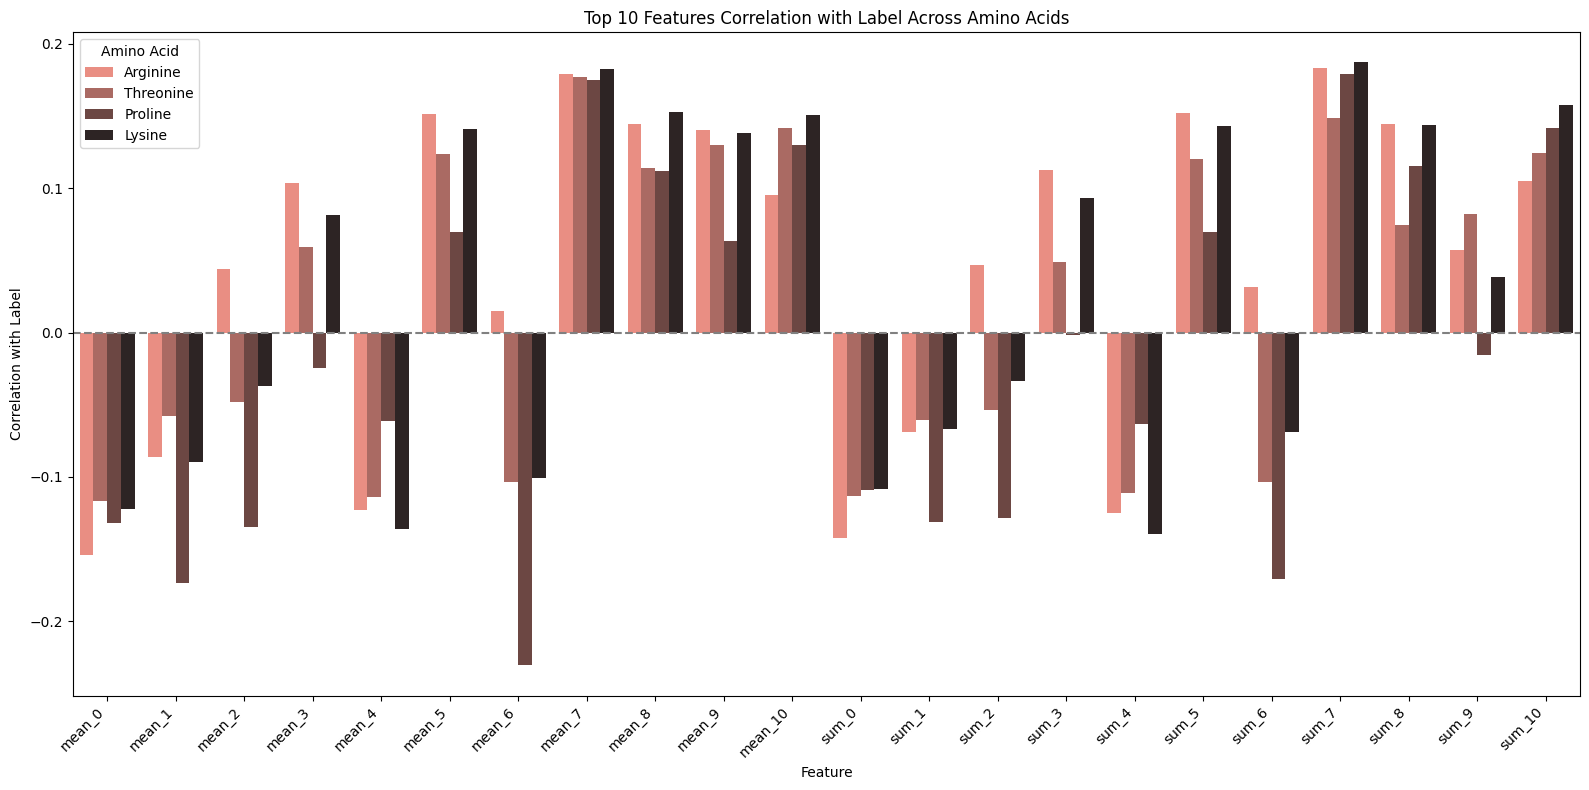

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast  # convert str to list


def safe_literal_eval(val):
    if isinstance(val, list):
        return val
    try:
        return ast.literal_eval(val)
    except Exception:
        return val


amino_acids_means = {
    "Arginine": dfs_by_top_and_mid_level_means["Training samples", "Arginine(R)"],
    "Threonine": dfs_by_top_and_mid_level_means["Training samples", "Threonine(T)"],
    "Proline": dfs_by_top_and_mid_level_means["Training samples", "Proline(P)"],
    "Lysine": dfs_by_top_and_mid_level_means["Training samples", "Lysine(K)"],
}

correlation_data = []

for aa_name, df in amino_acids_means.items():
    df = df.copy()
    df["aaindex_mean_vector"] = df["aaindex_mean_vector"].apply(safe_literal_eval)
    df["aaindex_sum_vector"] = df["aaindex_sum_vector"].apply(safe_literal_eval)

    mean_df = pd.DataFrame(df["aaindex_mean_vector"].to_list()).add_prefix("mean_")
    sum_df = pd.DataFrame(df["aaindex_sum_vector"].to_list()).add_prefix("sum_")

    mean_df["label"] = df["label"].values
    sum_df["label"] = df["label"].values

    mean_corr = mean_df.corr()["label"].drop("label")
    sum_corr = sum_df.corr()["label"].drop("label")

    for feature, corr_value in mean_corr.items():
        correlation_data.append(
            {
                "AminoAcid": aa_name,
                "Feature": feature,
                "CorrelationWithLabel": corr_value,
                "VectorType": "Mean",
            }
        )
    for feature, corr_value in sum_corr.items():
        correlation_data.append(
            {
                "AminoAcid": aa_name,
                "Feature": feature,
                "CorrelationWithLabel": corr_value,
                "VectorType": "Sum",
            }
        )

corr_df = pd.DataFrame(correlation_data)

plt.figure(figsize=(16, 8))
sns.barplot(
    data=corr_df,
    x="Feature",
    y="CorrelationWithLabel",
    hue="AminoAcid",
    palette="dark:salmon_r",
)
plt.title("Top 10 Features Correlation with Label Across Amino Acids")
plt.ylabel("Correlation with Label")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, color="gray", linestyle="--")
plt.legend(title="Amino Acid")
plt.tight_layout()
plt.savefig("correlation_for_vectors.png", dpi=300)
plt.show()

# Models


In [26]:
from typing import List
from sklearn.discriminant_analysis import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np
import json


class CategoryDataContainer:
    category: str

    train_df_mean: PandasDataFrame
    test_df_mean: PandasDataFrame

    train_df_props: PandasDataFrame
    test_df_props: PandasDataFrame

    train_df_props_no_x: PandasDataFrame
    test_df_props_no_x: PandasDataFrame

    labels_train: List[str]
    labels_test: List[str]

    labels_train_no_x: List[str]
    labels_test_no_x: List[str]

    accuracies_props: Dict[str, float] = {}
    accuracies_props_no_x: Dict[str, float] = {}
    accuracies_mean_mean: Dict[str, float] = {}
    accuracies_mean_sum: Dict[str, float] = {}

    f1_props: Dict[str, float] = {}
    f1_props_no_x: Dict[str, float] = {}
    f1_mean_mean: Dict[str, float] = {}
    f1_mean_sum: Dict[str, float] = {}

    models_props = {
        "Dummy (uniform)": DummyClassifier(strategy="uniform", random_state=42),
        "Dummy (most frequent)": DummyClassifier(
            strategy="most_frequent", random_state=42
        ),
        # 'Dummy (stratified)': DummyClassifier(strategy='stratified', random_state=42),
        "LogisticRegression": LogisticRegression(
            max_iter=1000, class_weight="balanced"
        ),
        "SVM": SVC(class_weight="balanced"),
        "GaussianNB": GaussianNB(),
        "RandomForest": RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
            n_estimators=500,
            min_samples_leaf=5,
        ),  # min_samples_leaf=5 to avoid overfitting
    }

    def __init__(
        self,
        category: str,
        train_df_mean: PandasDataFrame,
        test_df_mean: PandasDataFrame,
        train_df_props: PandasDataFrame,
        test_df_props: PandasDataFrame,
        train_df_props_no_x: PandasDataFrame,
        test_df_props_no_x: PandasDataFrame,
    ):
        self.category = category

        self.train_df_mean = train_df_mean.drop(columns=["label", "sequence"])
        self.test_df_mean = test_df_mean.drop(columns=["label", "sequence"])

        self.train_df_props = train_df_props.drop(columns=["label", "sequence"])
        self.test_df_props = test_df_props.drop(columns=["label", "sequence"])

        self.train_df_props_no_x = train_df_props_no_x.drop(
            columns=["label", "sequence"]
        )
        self.test_df_props_no_x = test_df_props_no_x.drop(columns=["label", "sequence"])

        self.labels_train = list(train_df_props["label"])
        self.labels_test = list(test_df_props["label"])

        self.labels_train_no_x = list(train_df_props_no_x["label"])
        self.labels_test_no_x = list(test_df_props_no_x["label"])

    def evaluate_models_on_props(self):
        scaler: StandardScaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(self.train_df_props)
        X_test_scaled = scaler.transform(self.test_df_props)

        for name, model in self.models_props.items():
            model.fit(X_train_scaled, self.labels_train)
            preds = model.predict(X_test_scaled)
            acc = accuracy_score(self.labels_test, preds)
            f1 = f1_score(
                self.labels_test, preds
            )  # by default it is binary, which gives the score for worse (underrepresented) class
            print(f"{name} accuracy (props): {acc:.4f}")
            print(f"{name} F1 score (props): {f1:.4f}")
            self.accuracies_props[name] = acc
            self.f1_props[name] = f1

    def evaluate_models_on_props_no_x(self):
        scaler: StandardScaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(self.train_df_props_no_x)
        X_test_scaled = scaler.transform(self.test_df_props_no_x)

        for name, model in self.models_props.items():
            model.fit(X_train_scaled, self.labels_train_no_x)
            preds = model.predict(X_test_scaled)
            acc = accuracy_score(self.labels_test_no_x, preds)
            f1 = f1_score(self.labels_test_no_x, preds)
            print(f"{name} accuracy (props no x): {acc:.4f}")
            print(f"{name} F1 score (props no x): {f1:.4f}")
            self.accuracies_props_no_x[name] = acc
            self.f1_props_no_x[name] = f1

    def _deserialize_vectors(self, series_json_str):
        list_of_vectors = series_json_str.apply(json.loads).tolist()
        return np.array(list_of_vectors)

    def evaluate_models_on_mean_mean(self):
        scaler: StandardScaler = StandardScaler()

        X_train = self._deserialize_vectors(self.train_df_mean["aaindex_mean_vector"])
        X_test = self._deserialize_vectors(self.test_df_mean["aaindex_mean_vector"])

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        for name, model in self.models_props.items():
            model.fit(X_train_scaled, self.labels_train)
            preds = model.predict(X_test_scaled)
            acc = accuracy_score(self.labels_test, preds)
            f1 = f1_score(self.labels_test, preds)
            print(f"{name} accuracy (mean vectors): {acc:.4f}")
            print(f"{name} F1 score (mean vectors): {f1:.4f}")
            self.accuracies_mean_mean[name] = acc
            self.f1_mean_mean[name] = f1

    def evaluate_models_on_mean_sum(self):
        scaler: StandardScaler = StandardScaler()

        X_train = self._deserialize_vectors(self.train_df_mean["aaindex_sum_vector"])
        X_test = self._deserialize_vectors(self.test_df_mean["aaindex_sum_vector"])

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        for name, model in self.models_props.items():
            model.fit(X_train_scaled, self.labels_train)
            preds = model.predict(X_test_scaled)
            acc = accuracy_score(self.labels_test, preds)
            f1 = f1_score(self.labels_test, preds)
            print(f"{name} accuracy (sum vectors): {acc:.4f}")
            print(f"{name} F1 score (sum vectors): {f1:.4f}")
            self.accuracies_mean_sum[name] = acc
            self.f1_mean_sum[name] = f1

    def plot_prop_accuracies_comparison_model_and_save_fig(self) -> None:
        models = [key for key in self.accuracies_props.keys() if "Dummy" not in key]

        dummies_acc_uniform = (
            self.accuracies_props.get("Dummy (uniform)")
            + self.accuracies_props_no_x.get("Dummy (uniform)")
        ) / 2
        dummies_acc_most_freq = (
            self.accuracies_props.get("Dummy (most frequent)")
            + self.accuracies_props_no_x.get("Dummy (most frequent)")
        ) / 2

        accuracies = [
            acc for key, acc in self.accuracies_props.items() if "Dummy" not in key
        ]
        accuracies_no_x = [
            acc for key, acc in self.accuracies_props_no_x.items() if "Dummy" not in key
        ]

        f1s = [f1 for key, f1 in self.f1_props.items() if "Dummy" not in key]
        f1s_no_x = [f1 for key, f1 in self.f1_props_no_x.items() if "Dummy" not in key]

        plt.figure(figsize=(10, 6))

        colors = {
            "accuracy_with_x": "#DAB3EB",
            "accuracy_no_x": "#C88EE1",
            "f1_with_x": "#B86EDC",
            "f1_no_x": "#9932CC",
        }

        bar_width = 0.18
        index = range(len(models))

        bars1 = plt.bar(
            [i - 1.5 * bar_width for i in index],
            accuracies,
            bar_width,
            color=colors["accuracy_with_x"],
            label="Accuracy (with X)",
            edgecolor="black",
            linewidth=0.5,
        )
        bars2 = plt.bar(
            [i - 0.5 * bar_width for i in index],
            accuracies_no_x,
            bar_width,
            color=colors["accuracy_no_x"],
            label="Accuracy (no X)",
            edgecolor="black",
            linewidth=0.5,
        )
        bars3 = plt.bar(
            [i + 0.5 * bar_width for i in index],
            f1s,
            bar_width,
            color=colors["f1_with_x"],
            label="F1-score (with X)",
            edgecolor="black",
            linewidth=0.5,
        )
        bars4 = plt.bar(
            [i + 1.5 * bar_width for i in index],
            f1s_no_x,
            bar_width,
            color=colors["f1_no_x"],
            label="F1-score (no X)",
            edgecolor="black",
            linewidth=0.5,
        )

        fontsize = 10

        for bars in [bars1, bars2, bars3, bars4]:
            for bar in bars:
                height = bar.get_height()
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + 0.01,
                    f"{height:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=fontsize,
                )

        plt.axhline(
            y=dummies_acc_uniform,
            color="black",
            linestyle="--",
            linewidth=1,
            label=f"Dummy (uniform): {dummies_acc_uniform:.2f}",
        )
        plt.axhline(
            y=dummies_acc_most_freq,
            color="black",
            linestyle=":",
            alpha=0.7,
            linewidth=2,
            label=f"Dummy (most frequent): {dummies_acc_most_freq:.2f}",
        )

        plt.xlabel("Model", weight="bold")
        plt.ylabel("Score", weight="bold")
        plt.title(
            f"Accuracies and F1-scores of models on {self.category} properties (props)",
            weight="bold",
        )

        plt.xticks(index, models, weight="bold", fontsize=fontsize)
        plt.ylim(0, 1.5)

        plt.tight_layout()
        plt.grid(axis="y", linestyle=":", alpha=0.6)
        plt.legend(
            loc="upper left",
            title="Metrics",
        )
        plt.savefig(
            f"{self.category}_model_accuracies_f1_props.png", bbox_inches="tight"
        )
        plt.show()

    def plot_mean_and_sum_accuracies_comparison_model_and_save_fig(self) -> None:
        models = [key for key in self.accuracies_mean_sum.keys() if "Dummy" not in key]

        dummies_acc_uniform = (
            self.accuracies_mean_mean.get("Dummy (uniform)")
            + self.accuracies_mean_sum.get("Dummy (uniform)")
        ) / 2
        dummies_acc_most_freq = (
            self.accuracies_mean_mean.get("Dummy (most frequent)")
            + self.accuracies_mean_sum.get("Dummy (most frequent)")
        ) / 2

        accuracies_mean = [
            acc for key, acc in self.accuracies_mean_mean.items() if "Dummy" not in key
        ]
        accuracies_sum = [
            acc for key, acc in self.accuracies_mean_sum.items() if "Dummy" not in key
        ]

        f1s_mean = [f1 for key, f1 in self.f1_mean_mean.items() if "Dummy" not in key]
        f1s_sum = [f1 for key, f1 in self.f1_mean_sum.items() if "Dummy" not in key]

        plt.figure(figsize=(10, 6))

        colors = {
            "accuracy_mean": "#8CE0EB",
            "accuracy_sum": "#45B6C5",
            "f1_mean": "#2194A3",
            "f1_sum": "#0C7886",
        }

        bar_width = 0.18
        index = range(len(models))

        bars1 = plt.bar(
            [i - 1.5 * bar_width for i in index],
            accuracies_mean,
            bar_width,
            color=colors["accuracy_mean"],
            label="Accuracy (mean)",
            edgecolor="black",
            linewidth=0.5,
        )
        bars2 = plt.bar(
            [i - 0.5 * bar_width for i in index],
            accuracies_sum,
            bar_width,
            color=colors["accuracy_sum"],
            label="Accuracy (sum)",
            edgecolor="black",
            linewidth=0.5,
        )
        bars3 = plt.bar(
            [i + 0.5 * bar_width for i in index],
            f1s_mean,
            bar_width,
            color=colors["f1_mean"],
            label="F1-score (mean)",
            edgecolor="black",
            linewidth=0.5,
        )
        bars4 = plt.bar(
            [i + 1.5 * bar_width for i in index],
            f1s_sum,
            bar_width,
            color=colors["f1_sum"],
            label="F1-score (sum)",
            edgecolor="black",
            linewidth=0.5,
        )

        fontsize = 10

        for bars in [bars1, bars2, bars3, bars4]:
            for bar in bars:
                height = bar.get_height()
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + 0.01,
                    f"{height:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=fontsize,
                )

        plt.axhline(
            y=dummies_acc_uniform,
            color="black",
            linestyle="--",
            linewidth=1,
            label=f"Dummy (uniform): {dummies_acc_uniform:.2f}",
        )
        plt.axhline(
            y=dummies_acc_most_freq,
            color="black",
            linestyle=":",
            alpha=0.7,
            linewidth=2,
            label=f"Dummy (most frequent): {dummies_acc_most_freq:.2f}",
        )

        plt.xlabel("Model", weight="bold")
        plt.ylabel("Score", weight="bold")
        plt.title(
            f"Accuracies and F1-scores of models on {self.category} properties (vectors)",
            weight="bold",
        )

        plt.xticks(index, models, weight="bold", fontsize=fontsize)
        plt.ylim(0, 1.5)

        plt.tight_layout()
        plt.grid(axis="y", linestyle=":", alpha=0.6)
        plt.legend(
            loc="upper left",
            title="Metrics",
        )
        plt.savefig(
            f"{self.category}_model_accuracies_f1_vectors.png", bbox_inches="tight"
        )
        plt.show()

# Results visualization


In [27]:
# Subsets names (proteins): {'Threonine(T)', 'Arginine(R)', 'Lysine(K)', 'Proline(P)'}

category_arginine = CategoryDataContainer(
    category="Arginine(R)",
    train_df_mean=dfs_by_top_and_mid_level_means[("Training samples", "Arginine(R)")],
    train_df_props=dfs_by_top_and_mid_level_props[("Training samples", "Arginine(R)")],
    train_df_props_no_x=dfs_by_top_and_mid_level_props_no_x[
        ("Training samples", "Arginine(R)")
    ],
    test_df_mean=dfs_by_top_and_mid_level_means[("Testing samples", "Arginine(R)")],
    test_df_props=dfs_by_top_and_mid_level_props[("Testing samples", "Arginine(R)")],
    test_df_props_no_x=dfs_by_top_and_mid_level_props_no_x[
        ("Testing samples", "Arginine(R)")
    ],
)

category_lysine = CategoryDataContainer(
    category="Lysine(K)",
    train_df_mean=dfs_by_top_and_mid_level_means[("Training samples", "Lysine(K)")],
    train_df_props=dfs_by_top_and_mid_level_props[("Training samples", "Lysine(K)")],
    train_df_props_no_x=dfs_by_top_and_mid_level_props_no_x[
        ("Training samples", "Lysine(K)")
    ],
    test_df_mean=dfs_by_top_and_mid_level_means[("Testing samples", "Lysine(K)")],
    test_df_props=dfs_by_top_and_mid_level_props[("Testing samples", "Lysine(K)")],
    test_df_props_no_x=dfs_by_top_and_mid_level_props_no_x[
        ("Testing samples", "Lysine(K)")
    ],
)

category_threonine = CategoryDataContainer(
    category="Threonine(T)",
    train_df_mean=dfs_by_top_and_mid_level_means[("Training samples", "Threonine(T)")],
    train_df_props=dfs_by_top_and_mid_level_props[("Training samples", "Threonine(T)")],
    train_df_props_no_x=dfs_by_top_and_mid_level_props_no_x[
        ("Training samples", "Threonine(T)")
    ],
    test_df_mean=dfs_by_top_and_mid_level_means[("Testing samples", "Threonine(T)")],
    test_df_props=dfs_by_top_and_mid_level_props[("Testing samples", "Threonine(T)")],
    test_df_props_no_x=dfs_by_top_and_mid_level_props_no_x[
        ("Testing samples", "Threonine(T)")
    ],
)

category_proline = CategoryDataContainer(
    category="Proline(P)",
    train_df_mean=dfs_by_top_and_mid_level_means[("Training samples", "Proline(P)")],
    train_df_props=dfs_by_top_and_mid_level_props[("Training samples", "Proline(P)")],
    train_df_props_no_x=dfs_by_top_and_mid_level_props_no_x[
        ("Training samples", "Proline(P)")
    ],
    test_df_mean=dfs_by_top_and_mid_level_means[("Testing samples", "Proline(P)")],
    test_df_props=dfs_by_top_and_mid_level_props[("Testing samples", "Proline(P)")],
    test_df_props_no_x=dfs_by_top_and_mid_level_props_no_x[
        ("Testing samples", "Proline(P)")
    ],
)

categories = [
    category_arginine,
    category_lysine,
    category_threonine,
    category_proline,
]

Evaluating category: Arginine(R)
----------------------------------------
Dummy (uniform) accuracy (props): 0.3545
Dummy (uniform) F1 score (props): 0.1235
Dummy (most frequent) accuracy (props): 0.8455
Dummy (most frequent) F1 score (props): 0.0000
LogisticRegression accuracy (props): 0.6727
LogisticRegression F1 score (props): 0.2800
SVM accuracy (props): 0.6636
SVM F1 score (props): 0.2449
GaussianNB accuracy (props): 0.8455
GaussianNB F1 score (props): 0.0000
RandomForest accuracy (props): 0.8273
RandomForest F1 score (props): 0.0000
------------------------------------------------------------
Dummy (uniform) accuracy (props no x): 0.3654
Dummy (uniform) F1 score (props no x): 0.0833
Dummy (most frequent) accuracy (props no x): 0.8750
Dummy (most frequent) F1 score (props no x): 0.0000
LogisticRegression accuracy (props no x): 0.6731
LogisticRegression F1 score (props no x): 0.2273
SVM accuracy (props no x): 0.7019
SVM F1 score (props no x): 0.2439
GaussianNB accuracy (props no x):

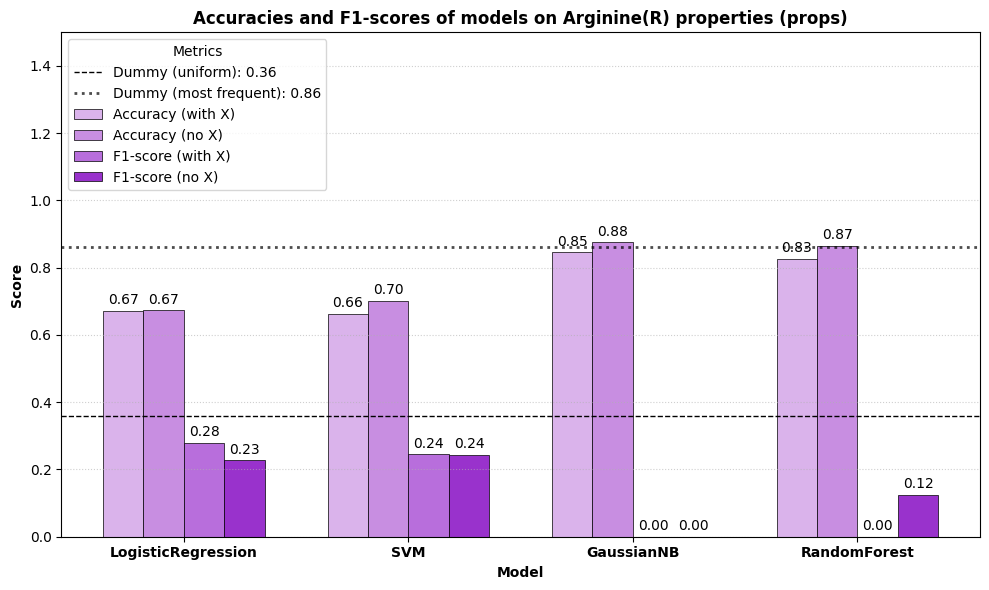

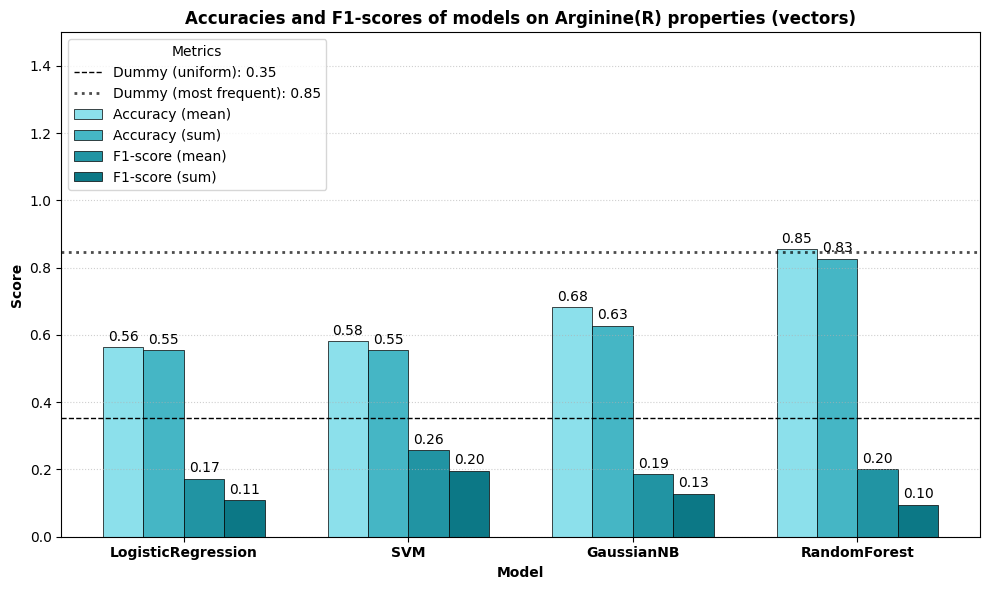

Evaluating category: Lysine(K)
----------------------------------------
Dummy (uniform) accuracy (props): 0.4917
Dummy (uniform) F1 score (props): 0.2812
Dummy (most frequent) accuracy (props): 0.8122
Dummy (most frequent) F1 score (props): 0.0000
LogisticRegression accuracy (props): 0.6409
LogisticRegression F1 score (props): 0.2857
SVM accuracy (props): 0.6298
SVM F1 score (props): 0.2299
GaussianNB accuracy (props): 0.7901
GaussianNB F1 score (props): 0.0500
RandomForest accuracy (props): 0.7845
RandomForest F1 score (props): 0.1333
------------------------------------------------------------
Dummy (uniform) accuracy (props no x): 0.4702
Dummy (uniform) F1 score (props no x): 0.2393
Dummy (most frequent) accuracy (props no x): 0.8333
Dummy (most frequent) F1 score (props no x): 0.0000
LogisticRegression accuracy (props no x): 0.6607
LogisticRegression F1 score (props no x): 0.2963
SVM accuracy (props no x): 0.6369
SVM F1 score (props no x): 0.2278
GaussianNB accuracy (props no x): 0

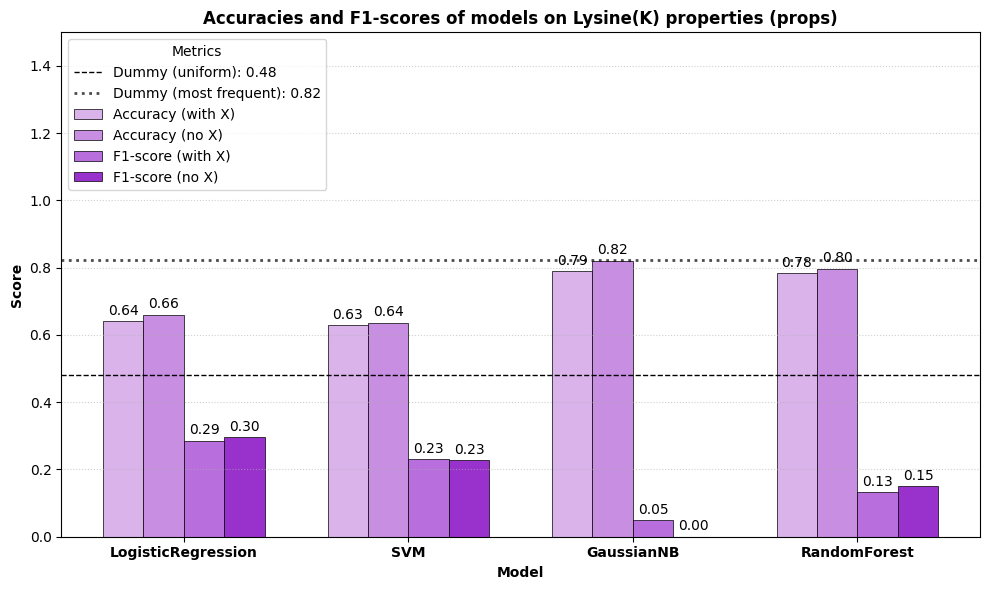

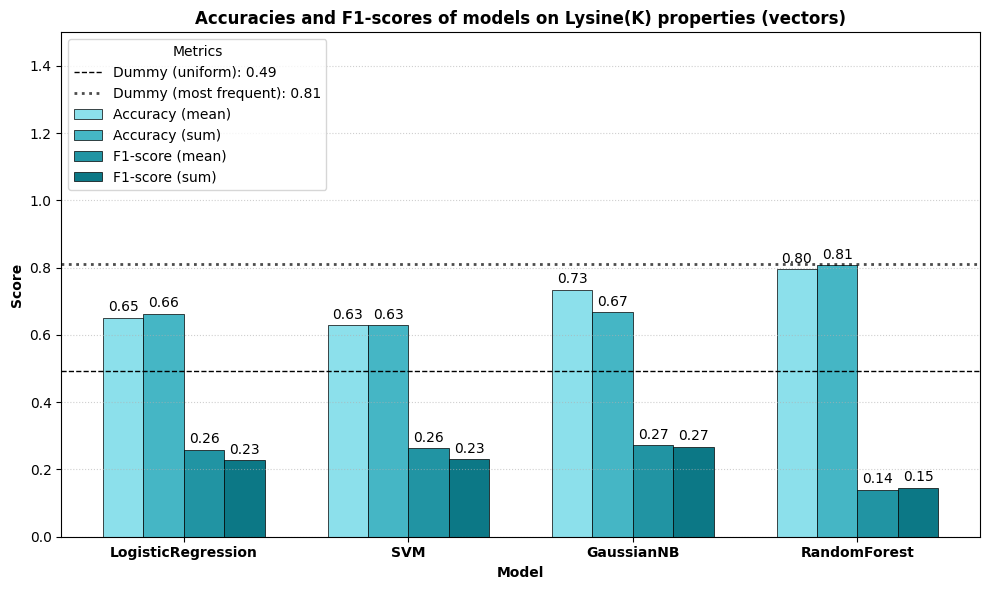

Evaluating category: Threonine(T)
----------------------------------------
Dummy (uniform) accuracy (props): 0.3714
Dummy (uniform) F1 score (props): 0.0833
Dummy (most frequent) accuracy (props): 0.8571
Dummy (most frequent) F1 score (props): 0.0000
LogisticRegression accuracy (props): 0.9429
LogisticRegression F1 score (props): 0.8000
SVM accuracy (props): 0.8857
SVM F1 score (props): 0.7143
GaussianNB accuracy (props): 0.9143
GaussianNB F1 score (props): 0.5714
RandomForest accuracy (props): 0.9429
RandomForest F1 score (props): 0.7500
------------------------------------------------------------
Dummy (uniform) accuracy (props no x): 0.3714
Dummy (uniform) F1 score (props no x): 0.0833
Dummy (most frequent) accuracy (props no x): 0.8571
Dummy (most frequent) F1 score (props no x): 0.0000
LogisticRegression accuracy (props no x): 0.9143
LogisticRegression F1 score (props no x): 0.7273
SVM accuracy (props no x): 0.8857
SVM F1 score (props no x): 0.7143
GaussianNB accuracy (props no x)

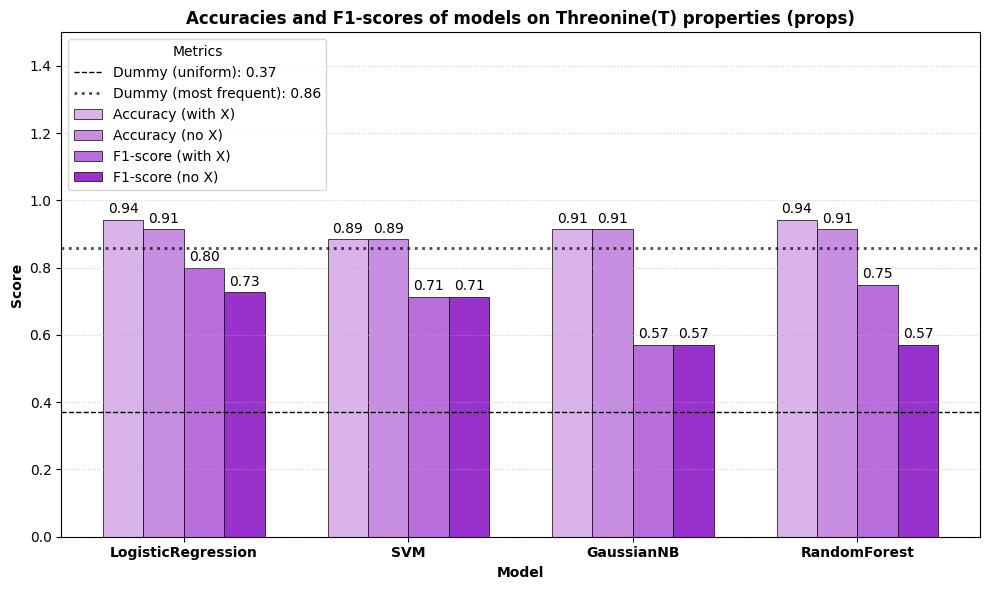

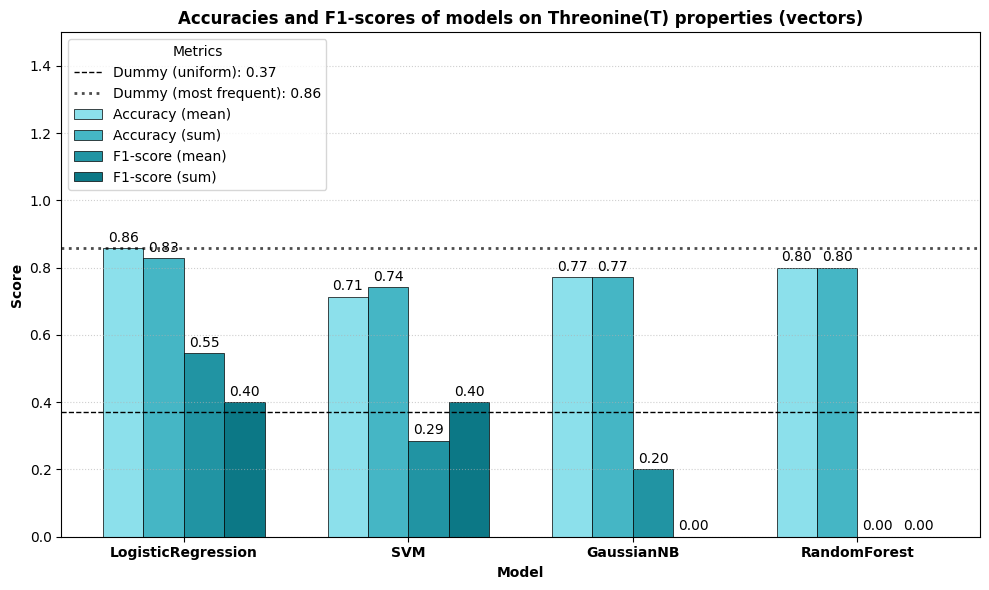

Evaluating category: Proline(P)
----------------------------------------
Dummy (uniform) accuracy (props): 0.4205
Dummy (uniform) F1 score (props): 0.1053
Dummy (most frequent) accuracy (props): 0.8636
Dummy (most frequent) F1 score (props): 0.0000
LogisticRegression accuracy (props): 0.7045
LogisticRegression F1 score (props): 0.1875
SVM accuracy (props): 0.6705
SVM F1 score (props): 0.2564
GaussianNB accuracy (props): 0.8523
GaussianNB F1 score (props): 0.1333
RandomForest accuracy (props): 0.8295
RandomForest F1 score (props): 0.2105
------------------------------------------------------------
Dummy (uniform) accuracy (props no x): 0.4118
Dummy (uniform) F1 score (props no x): 0.1071
Dummy (most frequent) accuracy (props no x): 0.8588
Dummy (most frequent) F1 score (props no x): 0.0000
LogisticRegression accuracy (props no x): 0.6941
LogisticRegression F1 score (props no x): 0.1875
SVM accuracy (props no x): 0.6824
SVM F1 score (props no x): 0.2703
GaussianNB accuracy (props no x): 

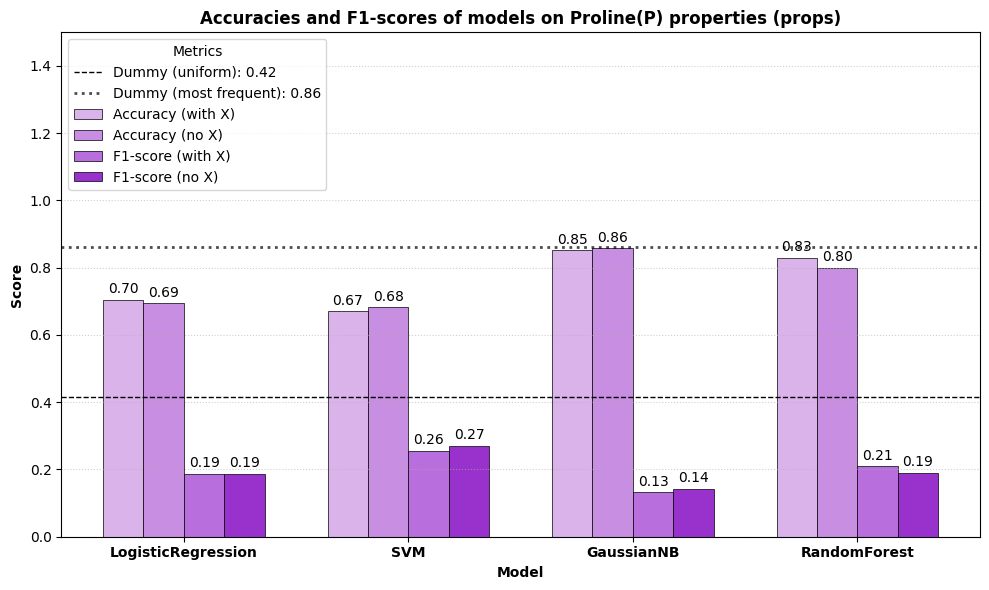

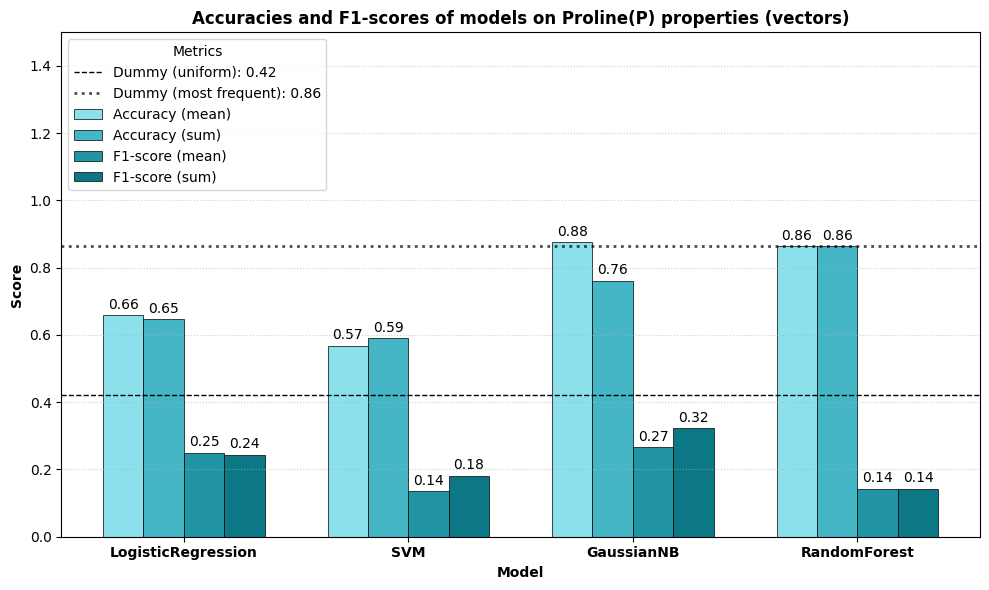

In [29]:
for category in categories:
    print(f"Evaluating category: {category.category}")
    print("-" * 40)
    category.evaluate_models_on_props()
    print("-" * 60)
    category.evaluate_models_on_props_no_x()
    print("-" * 60)
    category.evaluate_models_on_mean_mean()
    print("-" * 60)
    category.evaluate_models_on_mean_sum()
    print("-" * 60)
    category.plot_prop_accuracies_comparison_model_and_save_fig()
    print("=" * 60)
    category.plot_mean_and_sum_accuracies_comparison_model_and_save_fig()
    print("=" * 60)

In [ ]:
# get means for table comparison

from collections import defaultdict
import numpy as np


def collect_means(categories, attr_name, exclude_key="Dummy"):
    results = defaultdict(list) # if key does not exist it will be created with an empty list
    for category in categories:
        attr = getattr(category, attr_name)
        for key, val in attr.items():
            if exclude_key not in key:
                results[key].append(val)
    return {key: np.mean(vals) for key, vals in results.items()} # thaks to defaultdict we don't have to worry if the key already exixts - if it doesn't it will be automatically created with an empty list


acc_props_mean = collect_means(categories, "accuracies_props")
acc_props_no_x_mean = collect_means(categories, "accuracies_props_no_x")
acc_mean_mean = collect_means(categories, "accuracies_mean_mean")
acc_sum_mean = collect_means(categories, "accuracies_mean_sum")

f1_props_mean = collect_means(categories, "f1_props")
f1_props_no_x_mean = collect_means(categories, "f1_props_no_x")
f1_mean_mean = collect_means(categories, "f1_mean_mean")
f1_sum_mean = collect_means(categories, "f1_mean_sum")


def print_means(title, means_dict):
    print(title)
    for key, val in means_dict.items():
        print(f"{key}: {val:.4f}")
    print()


print_means("Mean Accuracy per key (props):", acc_props_mean)
print_means("Mean Accuracy per key (props no x):", acc_props_no_x_mean)
print_means("Mean Accuracy per key (mean):", acc_mean_mean)
print_means("Mean Accuracy per key (sum):", acc_sum_mean)

print_means("Mean F1-score per key (props):", f1_props_mean)
print_means("Mean F1-score per key (props no x):", f1_props_no_x_mean)
print_means("Mean F1-score per key (mean):", f1_mean_mean)
print_means("Mean F1-score per key (sum):", f1_sum_mean)


Mean Accuracy per key (props):
LogisticRegression: 0.7045
SVM: 0.6705
GaussianNB: 0.8523
RandomForest: 0.8295

Mean Accuracy per key (props no x):
LogisticRegression: 0.6941
SVM: 0.6824
GaussianNB: 0.8588
RandomForest: 0.8000

Mean Accuracy per key (mean):
LogisticRegression: 0.6591
SVM: 0.5682
GaussianNB: 0.8750
RandomForest: 0.8636

Mean Accuracy per key (sum):
LogisticRegression: 0.6477
SVM: 0.5909
GaussianNB: 0.7614
RandomForest: 0.8636

Mean F1-score per key (props):
LogisticRegression: 0.1875
SVM: 0.2564
GaussianNB: 0.1333
RandomForest: 0.2105

Mean F1-score per key (props no x):
LogisticRegression: 0.1875
SVM: 0.2703
GaussianNB: 0.1429
RandomForest: 0.1905

Mean F1-score per key (mean):
LogisticRegression: 0.2500
SVM: 0.1364
GaussianNB: 0.2667
RandomForest: 0.1429

Mean F1-score per key (sum):
LogisticRegression: 0.2439
SVM: 0.1818
GaussianNB: 0.3226
RandomForest: 0.1429



# Bonus ✨


In [31]:
def sequences_to_lstm_ready_array(
    df: pd.DataFrame, max_len=27
) -> tuple[np.ndarray, np.ndarray]:
    aaindex = parse_aaindex1_modified("aaindex1")
    feature_keys = list(selected_features.keys())  # get features in correct order

    X_list = []
    y_list = []

    for _, row in df.iterrows():
        sequence = row["sequence"]
        label = row["label"]
        encoded = []

        for aa in sequence:
            aa_features = [
                aaindex.get(idx, {}).get("values", {}).get(aa, np.nan)
                for idx in feature_keys
            ]
            encoded.append(aa_features)

        encoded = np.array(encoded, dtype=np.float32)

        # if there is any NaN value in a sequence - continue
        if np.isnan(encoded).any():
            continue

        X_list.append(encoded)
        y_list.append(label)

    # create matrix for our lstm 😎
    X = np.stack(X_list)
    y = np.array(y_list)
    return X, y

In [32]:
dfs_by_top_and_mid_level_embeddings = (
    iterate_over_dfs_by_top_and_mid_level_and_apply_function(
        dfs_by_top_and_mid_level, sequences_to_lstm_ready_array
    )
)
dfs_by_top_and_mid_level_embeddings[("Training samples", "Lysine(K)")][0][0]

array([[ 1.880e+00,  2.980e-01,  0.000e+00,  5.520e+01, -1.300e+00,
         9.800e-01,  5.660e+00,  6.200e+00,  4.200e-01, -1.686e+00,
         1.227e+00],
       [ 6.000e-01,  2.910e-01,  1.000e+00,  9.470e+01, -4.500e+00,
         3.890e+00,  1.076e+01,  1.050e+01,  5.290e-01, -1.475e+00,
         1.725e+00],
       [ 6.000e-02,  1.340e-01,  0.000e+00,  6.010e+01, -3.500e+00,
         2.270e+00,  5.410e+00,  1.160e+01,  4.630e-01, -1.560e+00,
         1.080e+00],
       [ 6.000e-02,  1.340e-01,  0.000e+00,  6.010e+01, -3.500e+00,
         2.270e+00,  5.410e+00,  1.160e+01,  4.630e-01, -1.560e+00,
         1.080e+00],
       [ 2.020e+00,  2.900e-01,  0.000e+00,  2.550e+01,  2.800e+00,
        -3.240e+00,  5.480e+00,  5.200e+00,  3.140e-01, -1.864e+00,
         8.030e-01],
       [ 6.100e-01,  4.600e-02,  0.000e+00,  2.780e+01,  1.800e+00,
        -6.700e-01,  6.000e+00,  8.100e+00,  3.570e-01, -1.895e+00,
         9.370e-01],
       [ 1.150e+00,  2.190e-01,  1.000e+00,  1.030e+02, -3

In [33]:
from collections import Counter

# helper funcaiton to calculate class weight for compensation of unbalances data

def calculate_class_weight(y_train) -> Dict[int, float]:
    class_counts = Counter(y_train)

    total = sum(list(class_counts.values()))
    n_classes = 2

    weight_0 = total / (n_classes * class_counts.get(0))
    weight_1 = total / (n_classes * class_counts.get(1))

    class_weight = {0: round(weight_0, 2), 1: round(weight_1, 2)}
    print(class_weight)
    return class_weight

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam


class LSTMDataContainer:
    def __init__(
        self,
        category: str,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_test: np.ndarray,
        y_test: np.ndarray,
    ):
        self.category = category

        self.X_train = X_train
        self.X_test = X_test

        self.label_encoder = LabelEncoder() # to make sure that labels are encoded as integers
        self.y_train_enc = self.label_encoder.fit_transform(y_train)
        self.y_test_enc = self.label_encoder.transform(y_test)

        self.num_classes = len(self.label_encoder.classes_)

        self.history = None
        self.model = None

        self.class_weight = calculate_class_weight(y_train)

    def build_model(self, lstm_units=32, dropout_rate=0.5): 
        self.model = Sequential()
        self.model.add(
            LSTM(lstm_units, input_shape=self.X_train.shape[1:], return_sequences=False)
        )
        # lstm_units - number of LSTM neurons per layer - we chose 32 not to overfit
        # return_sequences=False - we want to return only the last output of the LSTM layer
        self.model.add(Dropout(dropout_rate)) # deactivete 50% of neurons to avoid overfitting
        self.model.add(Dense(self.num_classes, activation="softmax")) # get the output of the model as probabilities for each class
        self.model.compile(
            loss="sparse_categorical_crossentropy", # labels are integers, so we use sparse categorical crossentropy
            optimizer=Adam(learning_rate=0.0003), # Adam optimizer with learning rate 0.0003, to provide more stable training
            metrics=["accuracy"], # monitor accuracy during training
        )

    def train(self, epochs=20, batch_size=32):
        # we chose batch size as a safe value
        # 16 would be too small (too many steps), 64 couls lead to overfitting
        if self.model is None:
            self.build_model()

        class_weight = self.class_weight

        self.history = self.model.fit(
            self.X_train,
            self.y_train_enc,
            epochs=epochs,
            batch_size=batch_size,
            verbose=2, # get info per epoch (loss & accuracy)
            class_weight=class_weight,
        )

    def evaluate(self):
        preds_prob = self.model.predict(self.X_test) # get probabilities for each class
        preds = np.argmax(preds_prob, axis=1) # get label

        acc = accuracy_score(self.y_test_enc, preds)
        f1 = f1_score(self.y_test_enc, preds)
        print(f"LSTM Model accuracy: {acc:.4f}")
        print(f"LSTM Model F1 score: {f1:.4f}")
        return acc, f1

    def plot_training_history(self):

        epochs = range(1, len(self.history.history["accuracy"]) + 1)

        fig, ax1 = plt.subplots(figsize=(10, 5))

        ax1.set_title(f"{self.category} - Training History", fontsize=14)
        ax1.set_xlabel("Epoch", fontsize=12)
        ax1.set_ylabel("Accuracy", color="tab:blue", fontsize=12)
        ax1.plot(
            epochs,
            self.history.history["accuracy"],
            label="Train Accuracy",
            color="tab:blue",
            marker="o",
        )
        ax1.tick_params(axis="y", labelcolor="tab:blue")
        ax1.set_ylim([0, 1])

        ax2 = ax1.twinx() # create a second y-axis for loss
        ax2.set_ylabel("Loss", color="tab:orange", fontsize=12)
        ax2.plot(
            epochs,
            self.history.history["loss"],
            label="Train Loss",
            color="tab:orange",
            linestyle="--",
            marker="x",
        )
        ax2.tick_params(axis="y", labelcolor="tab:orange")

        accuracy, f1 = self.evaluate()

        fig.tight_layout()
        fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2)
        fig.text(
            0.5,
            -0.01,
            f"Accuracy: {accuracy:.2f} | F1-score: {f1:.2f}",
            ha="center",
            fontsize=12,
            fontweight="bold",
        )
        plt.savefig(f"{self.category}_training_history_lstm.png", bbox_inches="tight")
        plt.show()

{0: 0.57, 1: 3.84}
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


64/64 - 2s - 38ms/step - accuracy: 0.3376 - loss: 0.7875
Epoch 2/20
64/64 - 1s - 9ms/step - accuracy: 0.4801 - loss: 0.7141
Epoch 3/20
64/64 - 1s - 10ms/step - accuracy: 0.5499 - loss: 0.7163
Epoch 4/20
64/64 - 1s - 15ms/step - accuracy: 0.4732 - loss: 0.7163
Epoch 5/20
64/64 - 0s - 5ms/step - accuracy: 0.4889 - loss: 0.7024
Epoch 6/20
64/64 - 0s - 5ms/step - accuracy: 0.5700 - loss: 0.7072
Epoch 7/20
64/64 - 1s - 9ms/step - accuracy: 0.5268 - loss: 0.6983
Epoch 8/20
64/64 - 0s - 5ms/step - accuracy: 0.5155 - loss: 0.7047
Epoch 9/20
64/64 - 1s - 10ms/step - accuracy: 0.5332 - loss: 0.6984
Epoch 10/20
64/64 - 0s - 5ms/step - accuracy: 0.5877 - loss: 0.6871
Epoch 11/20
64/64 - 1s - 10ms/step - accuracy: 0.5705 - loss: 0.6949
Epoch 12/20
64/64 - 0s - 5ms/step - accuracy: 0.4973 - loss: 0.6908
Epoch 13/20
64/64 - 0s - 5ms/step - accuracy: 0.5961 - loss: 0.6664
Epoch 14/20
64/64 - 1s - 12ms/step - accuracy: 0.5445 - loss: 0.6832
Epoch 15/20
64/64 - 1s - 9ms/step - accuracy: 0.5686 - loss: 0

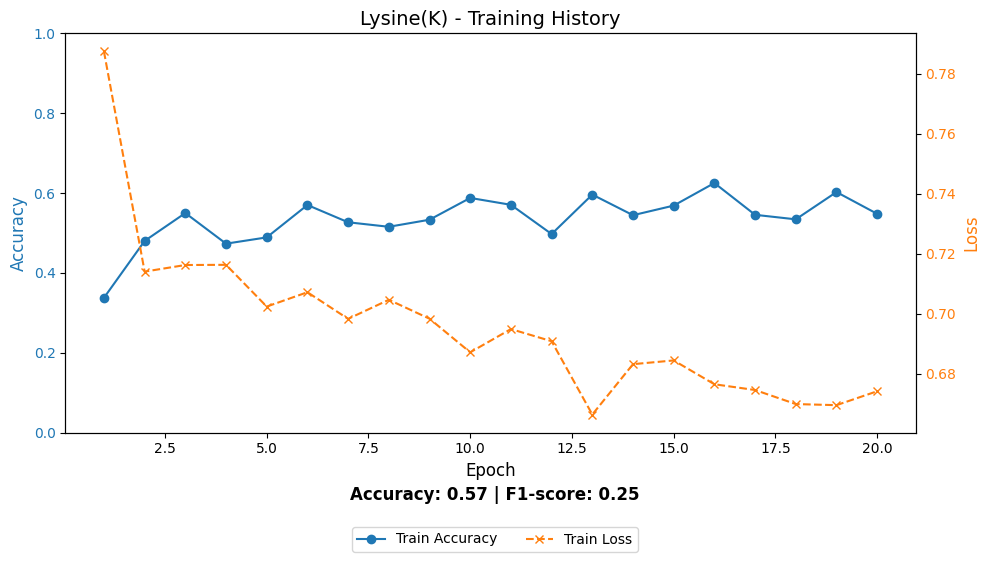

In [ ]:
# let's try for only one category

X_train, y_train = dfs_by_top_and_mid_level_embeddings[
    ("Training samples", "Lysine(K)")
]
X_test, y_test = dfs_by_top_and_mid_level_embeddings[("Testing samples", "Lysine(K)")]

proline_lstm = LSTMDataContainer(
    category="Lysine(K)", X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test
)

proline_lstm.build_model(lstm_units=64, dropout_rate=0.3)
proline_lstm.train(epochs=20, batch_size=32)

# evaluate
accuracy, f1 = proline_lstm.evaluate()

# trainign history
proline_lstm.plot_training_history()


{0: 0.58, 1: 3.58}
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 - 1s - 52ms/step - accuracy: 0.6089 - loss: 0.7183
Epoch 2/20
26/26 - 0s - 6ms/step - accuracy: 0.4641 - loss: 0.7074
Epoch 3/20
26/26 - 0s - 6ms/step - accuracy: 0.4827 - loss: 0.7069
Epoch 4/20
26/26 - 0s - 11ms/step - accuracy: 0.5260 - loss: 0.6955
Epoch 5/20
26/26 - 0s - 6ms/step - accuracy: 0.5532 - loss: 0.7143
Epoch 6/20
26/26 - 0s - 11ms/step - accuracy: 0.5866 - loss: 0.6775
Epoch 7/20
26/26 - 0s - 6ms/step - accuracy: 0.5693 - loss: 0.7043
Epoch 8/20
26/26 - 0s - 6ms/step - accuracy: 0.5792 - loss: 0.6903
Epoch 9/20
26/26 - 0s - 11ms/step - accuracy: 0.6225 - loss: 0.6492
Epoch 10/20
26/26 - 0s - 6ms/step - accuracy: 0.6238 - loss: 0.6831
Epoch 11/20
26/26 - 0s - 6ms/step - accuracy: 0.5297 - loss: 0.6860
Epoch 12/20
26/26 - 0s - 6ms/step - accuracy: 0.5978 - loss: 0.6593
Epoch 13/20
26/26 - 0s - 6ms/step - accuracy: 0.6720 - loss: 0.6492
Epoch 14/20
26/26 - 0s - 6ms/step - accuracy: 0.6163 - loss: 0.6491
Epoch 15/20
26/26 - 0s - 6ms/step - accuracy: 0.6188 - loss: 0.6

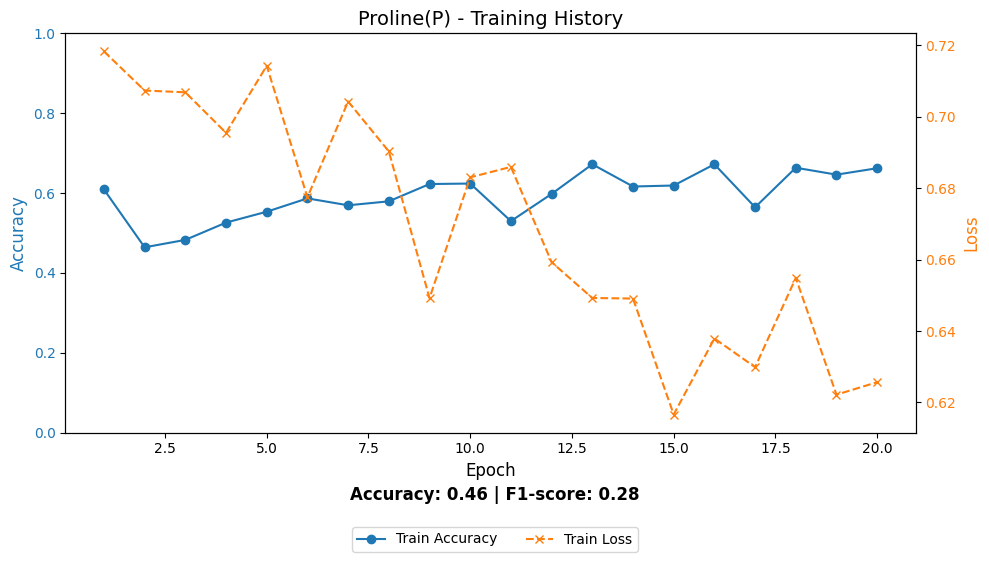

In [ ]:
X_train, y_train = dfs_by_top_and_mid_level_embeddings[
    ("Training samples", "Proline(P)")
]
X_test, y_test = dfs_by_top_and_mid_level_embeddings[("Testing samples", "Proline(P)")]

proline_lstm = LSTMDataContainer(
    category="Proline(P)",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)

proline_lstm.build_model(lstm_units=64, dropout_rate=0.3)
proline_lstm.train(epochs=20, batch_size=32)

accuracy, f1 = proline_lstm.evaluate()

proline_lstm.plot_training_history()

{0: 0.58, 1: 3.54}
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 - 1s - 54ms/step - accuracy: 0.3891 - loss: 0.7655
Epoch 2/20
26/26 - 0s - 11ms/step - accuracy: 0.5564 - loss: 0.7215
Epoch 3/20
26/26 - 0s - 6ms/step - accuracy: 0.5180 - loss: 0.7091
Epoch 4/20
26/26 - 0s - 6ms/step - accuracy: 0.5366 - loss: 0.7425
Epoch 5/20
26/26 - 0s - 12ms/step - accuracy: 0.5068 - loss: 0.7499
Epoch 6/20
26/26 - 0s - 11ms/step - accuracy: 0.5031 - loss: 0.7203
Epoch 7/20
26/26 - 0s - 12ms/step - accuracy: 0.4312 - loss: 0.7373
Epoch 8/20
26/26 - 0s - 6ms/step - accuracy: 0.5378 - loss: 0.7107
Epoch 9/20
26/26 - 0s - 6ms/step - accuracy: 0.5019 - loss: 0.7361
Epoch 10/20
26/26 - 0s - 6ms/step - accuracy: 0.4932 - loss: 0.6887
Epoch 11/20
26/26 - 0s - 6ms/step - accuracy: 0.5539 - loss: 0.7179
Epoch 12/20
26/26 - 0s - 12ms/step - accuracy: 0.5242 - loss: 0.7012
Epoch 13/20
26/26 - 0s - 11ms/step - accuracy: 0.5638 - loss: 0.6932
Epoch 14/20
26/26 - 0s - 6ms/step - accuracy: 0.5799 - loss: 0.6859
Epoch 15/20
26/26 - 0s - 12ms/step - accuracy: 0.5378 - loss:

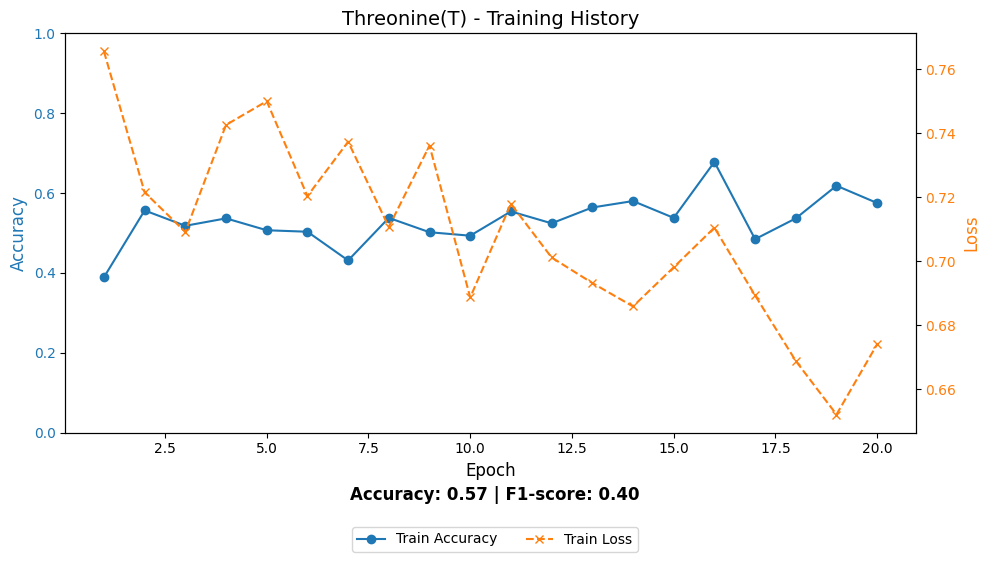

In [ ]:
X_train, y_train = dfs_by_top_and_mid_level_embeddings[
    ("Training samples", "Threonine(T)")
]
X_test, y_test = dfs_by_top_and_mid_level_embeddings[
    ("Testing samples", "Threonine(T)")
]

proline_lstm = LSTMDataContainer(
    category="Threonine(T)",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)

proline_lstm.build_model(lstm_units=64, dropout_rate=0.3)
proline_lstm.train(epochs=20, batch_size=32)

accuracy, f1 = proline_lstm.evaluate()

proline_lstm.plot_training_history()

{0: 0.58, 1: 3.6}
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 - 2s - 72ms/step - accuracy: 0.2161 - loss: 0.7940
Epoch 2/20
27/27 - 0s - 10ms/step - accuracy: 0.4182 - loss: 0.7018
Epoch 3/20
27/27 - 0s - 11ms/step - accuracy: 0.5199 - loss: 0.7189
Epoch 4/20
27/27 - 0s - 11ms/step - accuracy: 0.4755 - loss: 0.7167
Epoch 5/20
27/27 - 0s - 11ms/step - accuracy: 0.5012 - loss: 0.7070
Epoch 6/20
27/27 - 0s - 6ms/step - accuracy: 0.5362 - loss: 0.6987
Epoch 7/20
27/27 - 0s - 11ms/step - accuracy: 0.4685 - loss: 0.7292
Epoch 8/20
27/27 - 0s - 6ms/step - accuracy: 0.5304 - loss: 0.7106
Epoch 9/20
27/27 - 0s - 6ms/step - accuracy: 0.4708 - loss: 0.7052
Epoch 10/20
27/27 - 0s - 11ms/step - accuracy: 0.5467 - loss: 0.7013
Epoch 11/20
27/27 - 0s - 6ms/step - accuracy: 0.4696 - loss: 0.7083
Epoch 12/20
27/27 - 0s - 11ms/step - accuracy: 0.4953 - loss: 0.7001
Epoch 13/20
27/27 - 0s - 11ms/step - accuracy: 0.4965 - loss: 0.7024
Epoch 14/20
27/27 - 0s - 6ms/step - accuracy: 0.6320 - loss: 0.6951
Epoch 15/20
27/27 - 0s - 11ms/step - accuracy: 0.5841 - los

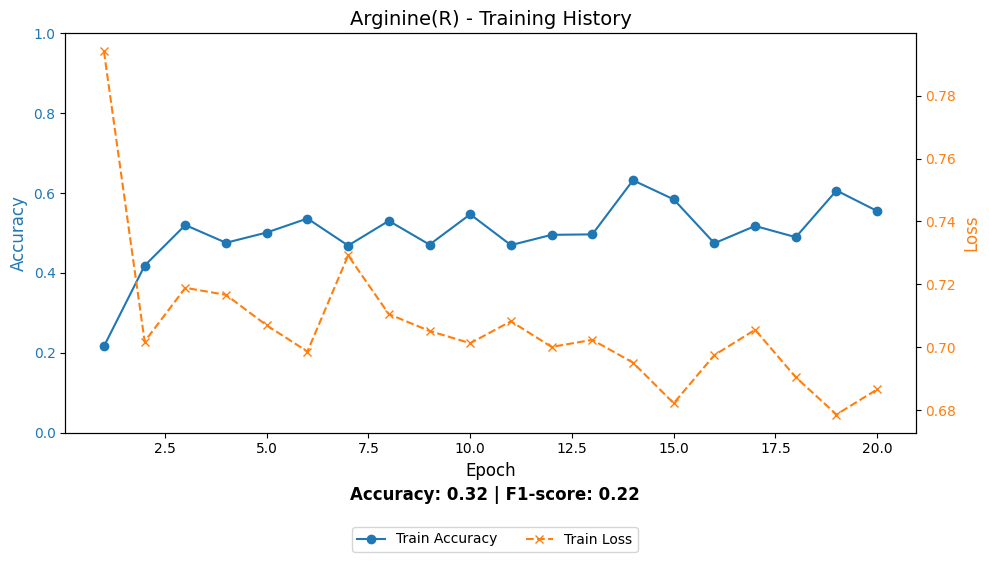

In [ ]:
X_train, y_train = dfs_by_top_and_mid_level_embeddings[
    ("Training samples", "Arginine(R)")
]
X_test, y_test = dfs_by_top_and_mid_level_embeddings[("Testing samples", "Arginine(R)")]

proline_lstm = LSTMDataContainer(
    category="Arginine(R)",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)

proline_lstm.build_model(lstm_units=64, dropout_rate=0.3)
proline_lstm.train(epochs=20, batch_size=32)

accuracy, f1 = proline_lstm.evaluate()

proline_lstm.plot_training_history()